# Lattice Size Comparison

This notebook will compare the size of the full partition lattice $\Pi_d$ - which is equal to the Bell number $B_d$ for a $d$ element set - with the size of the bond lattice for certain key graphs we have analysed. We know that the bond lattice of a complete graph with $d$ vertices, $K_n$, is isomorphic to $\Pi_n$, hence we will use the number of bonds found by our algorithm for the complete graphs to show the scaling of the partition lattice. This notebook generates Figure $5.1$ in the report.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import seaborn as sns
from Modules.bond_finders import *

sns.set_theme(style="whitegrid")

In [2]:
# Evaluating number of bonds / bond lattice size for different graphs

interval = np.arange(0, 9)

lattice_sizes = np.zeros((4, 9))
for n in interval:
    path = nx.path_graph(n)
    cycle = nx.cycle_graph(n)
    comp = nx.complete_graph(n)
    wheel = nx.wheel_graph(n)
    lattice_sizes[0, n] = len(walk_bond_finder(comp))
    lattice_sizes[1, n] = len(walk_bond_finder(wheel))
    lattice_sizes[2, n] = len(walk_bond_finder(cycle))
    lattice_sizes[3, n] = len(walk_bond_finder(path))

In [3]:
print(f"K_8 size: {int(lattice_sizes[0, 8])}")
print(f"W_8 size: {int(lattice_sizes[1, 8])}")
print(f"C_8 size: {int(lattice_sizes[2, 8])}")
print(f"P_8 size: {int(lattice_sizes[3, 8])}")

K_8 size: 4140
W_8 size: 836
C_8 size: 248
P_8 size: 128


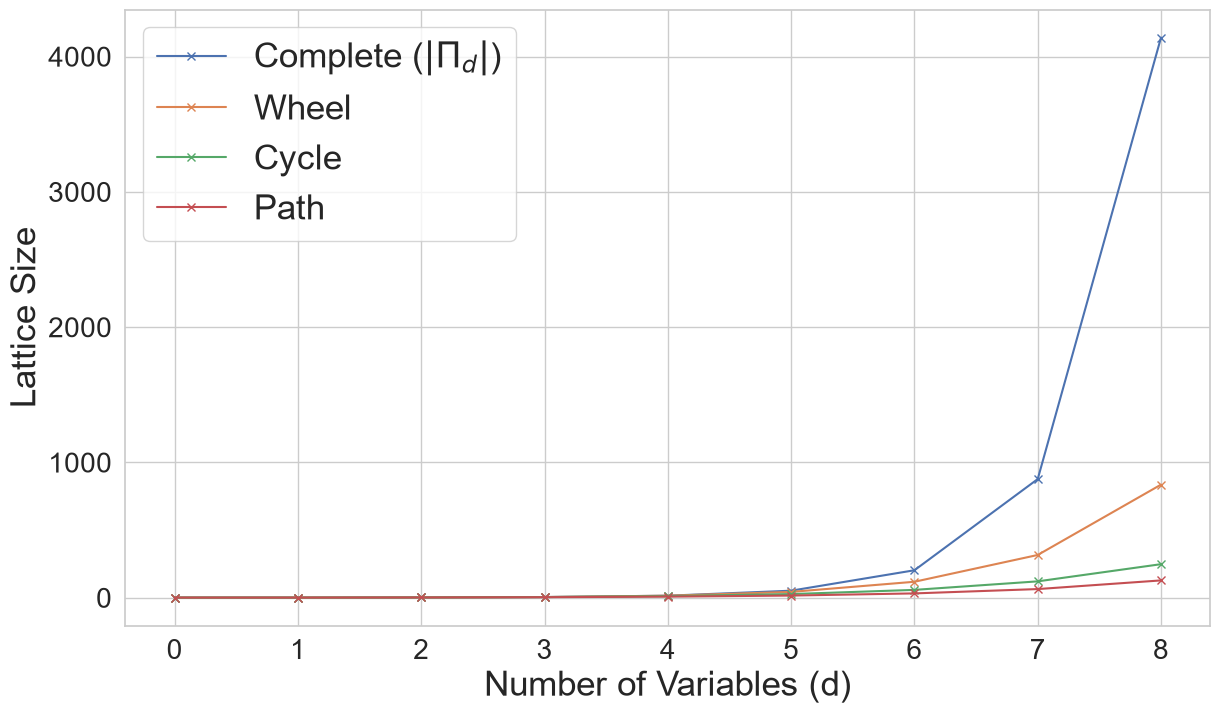

In [4]:
# Plotting

legend = {0 : rf"Complete ($|\Pi_d|$)", 1 : "Wheel", 2 : "Cycle", 3 : "Path"}

plt.figure(figsize=(14,8))

for i in range(4):
    plt.plot(lattice_sizes[i, :], label = legend[i], marker = "x")

plt.xlabel("Number of Variables (d)", fontsize=25)
plt.ylabel("Lattice Size", fontsize=25)
plt.legend(fontsize=25)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.savefig(r"C:\Users\morit\Thesis_Repo\Plots\lattice_size_plot.pdf")
plt.show()